> **Requires a repository checkout.** This notebook loads a frozen artifact from
> `demos/data/`, which is not shipped in the published `transformer_lens` wheel. Run it from
> a clone of the repository; the load cell below fails with that requirement spelled out if
> the artifact is missing.


# Coordinate-patch causal-swap benchmark

`JacobianLens.coordinate_patch_hooks` installs an anchored J-space coordinate edit live
inside a forward pass. This notebook asks whether that edit causes a directional change in
model output, under three controls:

- **Baseline-capability filtering.** A prompt only enters the intervention trials if the
  unperturbed model already answers it correctly; a swap is never scored against a prompt
  the model already gets wrong. A baseline whose answer is tied for the top logit is treated
  as not capable, since `argmax` would otherwise let token-id order decide admission.
- **Displacement-matched random-atom control.** Every real trial (patch toward the actual
  target concept) is paired with a control trial that patches toward a token whose
  lens-dictionary atom sits at the same displacement from the source atom as the real
  target's, within a fixed relative tolerance. The perturbation is
  `c_src * (a_target - a_source)`, so its size is set by `||a_target - a_source||`; matching
  atom norms instead would leave that size free. This isolates "swapping toward this concept
  mattered" from "any coordinate edit of this magnitude would have mattered." Each trial
  draws its control arm under several seeds and records every draw, because a single draw
  leaves the control arm's own variance unmeasured.
- **Exact Clopper-Pearson intervals.** Every reported success rate carries an exact 95%
  interval, not a bare point estimate. A percentile bootstrap cannot express uncertainty
  about an all-failure sample: it collapses to `[0, 0]` whether the run had one trial or a
  thousand, whereas the exact upper bound for 0 of 6 is 0.46.

Each trial installs `coordinate_patch_hooks` at exactly **one** layer and the final prompt
position -- a single-layer intervention, not a multi-layer band. A trial whose source concept
is not active in that layer's support, or whose layer admits no displacement-matched control,
is recorded as skipped, not silently dropped and not counted as a failure. Because several
trials can share one prompt, the pooled rate also travels with the number of independent
prompts behind it.

**This notebook loads a frozen artifact and never calls the model.** The artifact was
generated once, out-of-band, by running the benchmark's CLI entry point; see the load cell
below for the exact command. Re-running the sweep is a separate, explicit step, not something
this notebook triggers.


In [1]:
# NBVAL_IGNORE_OUTPUT
import os

IN_GITHUB = os.getenv("GITHUB_ACTIONS") == "true"
print("Running under GitHub Actions" if IN_GITHUB else "Running locally")


Running locally


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd

from transformer_lens.tools.analysis import load_artifact, success_rate_ci

ARTIFACT_NAME = "jacobian_lens_causal_swap_benchmark_gpt2.json"


def _find_artifact() -> Path:
    """Locates the frozen artifact from a repository checkout.

    The artifact lives under ``demos/data/``, which the published wheel does not ship, so
    this notebook only runs from a checkout. Searched upward from the working directory so
    the notebook works whether it is launched from ``demos/`` or the repository root.
    """
    for root in [Path.cwd(), *Path.cwd().parents]:
        candidate = root / "demos" / "data" / ARTIFACT_NAME
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"could not find demos/data/{ARTIFACT_NAME} in {Path.cwd()} or any parent "
        "directory. This notebook requires a repository checkout: it loads a frozen "
        "artifact that is not packaged in the transformer_lens wheel. Clone the repository "
        "and run the notebook from within it, or regenerate the artifact with "
        "`uv run python -m transformer_lens.tools.analysis."
        "jacobian_lens_causal_swap_benchmark_cli`."
    )


ARTIFACT_PATH = _find_artifact()
REPO_ROOT = ARTIFACT_PATH.parents[2]
artifact = load_artifact(ARTIFACT_PATH)
manifest = artifact["protocol_manifest"]
print(f"artifact={ARTIFACT_PATH.relative_to(REPO_ROOT)}")
print(f"schema_version={artifact['schema_version']}")
print(f"protocol_fingerprint={artifact['protocol_fingerprint']}")
print(f"results_fingerprint={artifact['results_fingerprint']}")
print(
    f"model={manifest['model_id']} lens={manifest['lens_repo']}/{manifest['lens_file']} "
    f"@{manifest['lens_revision']}"
)
print(
    f"corpus={manifest['corpus_name']} "
    f"(from {manifest['corpus_repo']}/{manifest['corpus_path']}@{manifest['corpus_revision']})"
)
print(f"layers_swept={manifest['layers_swept']} layers_executed={artifact['layers_executed']}")
print(f"alpha={manifest['alpha']} control_seeds={manifest['control_seeds']}")

artifact=demos/data/jacobian_lens_causal_swap_benchmark_gpt2.json
schema_version=2
protocol_fingerprint=b831263c046c1110ff56ddc4858b3aea41cd9677a6a04331d5563e554a33d65f
results_fingerprint=05321a650108369fafb68c59cc159502a3c46fb6a553cdd82a84e40cbcf7c12b
model=gpt2 lens=neuronpedia/jacobian-lens/gpt2-small/jlens/Salesforce-wikitext/gpt2_jacobian_lens.pt @a4114d7752d11eb546e6cf372213d7e75526d3a1
corpus=countries (from anthropics/jacobian-lens/data/experiments/flexible-generalization.json@581d398613e5602a5af361e1c34d3a92ea82ba8e)
layers_swept=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10] layers_executed=[9, 10]
alpha=1.0 control_seeds=[0, 1, 2, 3, 4]


## Baseline coverage and per-function success

The unconditional country/function corpus is reused from the existing `swap_hooks`
country-swap demo; here it runs against GPT-2-small rather than gemma-2-2b, and only prompts
that survive the baseline-capability filter reach the intervention trials below.

`executed_trials` counts trials where the source concept was active in the patched layer's
support (so a real and control condition both ran); `skipped_trials` counts the rest, which
are reported beside the executed count rather than hidden. Most of the sweep is skipped: the
source concept is active in only a couple of the swept layers, so the layers that actually
execute are listed separately from the layers that were requested. A function with no
executed trials still has its excluded-baseline and skipped counts reported -- it is not
silently omitted.


In [3]:
trials_df = pd.DataFrame(artifact["trials"])
excluded_df = pd.DataFrame(artifact["excluded_baselines"])

ok_df = trials_df[trials_df["status"] == "ok"].copy()
ok_df["real_success"] = ok_df["real_target_metrics"].apply(lambda m: m["target_is_top1"])
ok_df["control_success"] = ok_df["control_target_metrics"].apply(lambda m: m["target_is_top1"])
ok_df["baseline_rank"] = ok_df["baseline"].apply(lambda m: m["target_rank"])
ok_df["real_rank"] = ok_df["real_target_metrics"].apply(lambda m: m["target_rank"])
ok_df["control_rank"] = ok_df["control_target_metrics"].apply(lambda m: m["target_rank"])
ok_df["control_token_id"] = ok_df["control_token_id"].astype(int)

functions = sorted(set(trials_df["function"]) | set(excluded_df["function"]))


def _rate_with_ci(successes):
    ci = success_rate_ci(successes)
    return f"{ci.point_estimate:.0%} [{ci.ci_low:.0%}, {ci.ci_high:.0%}]"


summary_rows = []
for function in functions:
    n_excluded = int((excluded_df["function"] == function).sum()) if len(excluded_df) else 0
    subset = ok_df[ok_df["function"] == function]
    skipped = int(((trials_df["function"] == function) & (trials_df["status"] != "ok")).sum())
    summary_rows.append(
        {
            "function": function,
            "excluded_baseline_prompts": n_excluded,
            "executed_trials": len(subset),
            "skipped_trials": skipped,
            "real_success": (
                _rate_with_ci(subset["real_success"].tolist()) if len(subset) else "n/a"
            ),
            "control_success": (
                _rate_with_ci(subset["control_success"].tolist()) if len(subset) else "n/a"
            ),
        }
    )

overall_real_ci = artifact["real_success_ci"]
overall_control_ci = artifact["control_success_ci"]
summary_rows.append(
    {
        "function": "overall",
        "excluded_baseline_prompts": len(excluded_df),
        "executed_trials": len(ok_df),
        "skipped_trials": int((trials_df["status"] != "ok").sum()),
        "real_success": (
            f"{overall_real_ci['point_estimate']:.0%} "
            f"[{overall_real_ci['ci_low']:.0%}, {overall_real_ci['ci_high']:.0%}]"
        ),
        "control_success": (
            f"{overall_control_ci['point_estimate']:.0%} "
            f"[{overall_control_ci['ci_low']:.0%}, {overall_control_ci['ci_high']:.0%}]"
        ),
    }
)

summary_table = pd.DataFrame(summary_rows)
print(
    f"pooled rate rests on {artifact['n_independent_prompts']} independent prompt(s); "
    f"executed layers {artifact['layers_executed']} of swept {manifest['layers_swept']}"
)
summary_table

pooled rate rests on 1 independent prompt(s); executed layers [9, 10] of swept [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


,function,excluded_baseline_prompts,executed_trials,skipped_trials,real_success,control_success
0,capital,3,0,33,n/a,n/a
1,continent,2,6,60,"0% [0%, 46%]","0% [0%, 46%]"
2,currency,4,0,0,n/a,n/a
3,language,1,0,99,n/a,n/a
4,overall,10,6,192,"0% [0%, 46%]","0% [0%, 46%]"


## Visual summary

Left: real (patch toward the actual target concept) versus control (patch toward a
displacement-matched random token) success by function, with exact 95% Clopper-Pearson
intervals. A function with no executed trials is marked **n/a** rather than plotted as zero.

Right: the control arm's own spread. Each row is one executed trial; the orange whisker spans
the per-seed control margins and the blue diamond is the real condition's margin. A single
control draw would leave this spread invisible.


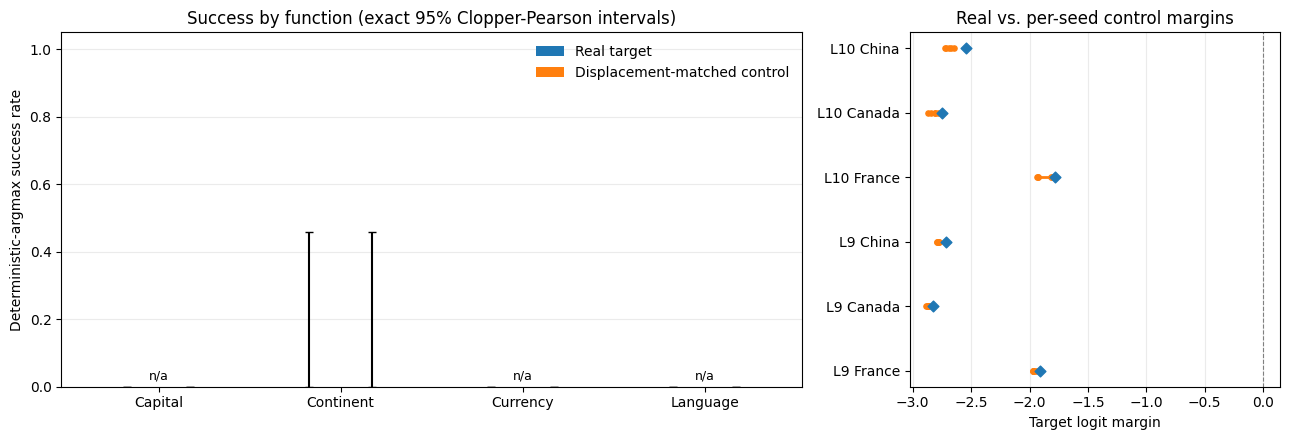

In [4]:
import matplotlib.pyplot as plt

plot_functions = [row["function"] for row in summary_rows if row["function"] != "overall"]
x = np.arange(len(plot_functions))
width = 0.35

real_values = []
real_errs = [[], []]
control_values = []
control_errs = [[], []]
has_data = []
for function in plot_functions:
    subset = ok_df[ok_df["function"] == function]
    if len(subset) == 0:
        has_data.append(False)
        real_values.append(0.0)
        control_values.append(0.0)
        real_errs[0].append(0.0)
        real_errs[1].append(0.0)
        control_errs[0].append(0.0)
        control_errs[1].append(0.0)
        continue
    has_data.append(True)
    real_ci = success_rate_ci(subset["real_success"].tolist())
    control_ci = success_rate_ci(subset["control_success"].tolist())
    real_values.append(real_ci.point_estimate)
    real_errs[0].append(real_ci.point_estimate - real_ci.ci_low)
    real_errs[1].append(real_ci.ci_high - real_ci.point_estimate)
    control_values.append(control_ci.point_estimate)
    control_errs[0].append(control_ci.point_estimate - control_ci.ci_low)
    control_errs[1].append(control_ci.ci_high - control_ci.point_estimate)

fig, (ax, spread_ax) = plt.subplots(
    1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [2, 1]}
)
ax.bar(x - width / 2, real_values, width, yerr=real_errs, capsize=3, label="Real target")
ax.bar(
    x + width / 2,
    control_values,
    width,
    yerr=control_errs,
    capsize=3,
    label="Displacement-matched control",
)
for i, present in enumerate(has_data):
    if not present:
        ax.annotate("n/a", (x[i], 0.02), ha="center", fontsize=9, color="black")
ax.set(
    ylabel="Deterministic-argmax success rate",
    xticks=x,
    xticklabels=[f.title() for f in plot_functions],
    ylim=(0, 1.05),
)
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.25)
ax.set_title("Success by function (exact 95% Clopper-Pearson intervals)")

spread_ax.axvline(0.0, color="grey", linewidth=0.8, linestyle="--")
spread_labels = []
for row_index, (_, trial) in enumerate(ok_df.iterrows()):
    margins = [draw["metrics"]["target_logit_margin"] for draw in trial["control_draws"]]
    spread_labels.append(f"L{trial['layer']} {trial['target']}")
    spread_ax.plot(
        [min(margins), max(margins)], [row_index, row_index], color="tab:orange", linewidth=2
    )
    spread_ax.scatter(margins, [row_index] * len(margins), color="tab:orange", s=14, zorder=3)
    spread_ax.scatter(
        [trial["real_target_metrics"]["target_logit_margin"]],
        [row_index],
        color="tab:blue",
        marker="D",
        s=30,
        zorder=4,
    )
spread_ax.set(
    xlabel="Target logit margin",
    yticks=range(len(spread_labels)),
    yticklabels=spread_labels,
    title="Real vs. per-seed control margins",
)
spread_ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
plt.show()

## Per-trial detail

Every trial that survived baseline filtering and had its source concept active in the patched
layer's support (`executed_trials` above). `control_token_id` is the raw vocabulary index of
the first seed's displacement-matched control token; this notebook does not load a tokenizer,
so it is not decoded to text here. `control_margin_min` / `control_margin_max` span the
per-seed control draws, so a reader can see whether the real condition's margin sits inside
the control arm's own range.


In [5]:
detail_columns = [
    "function",
    "source",
    "target",
    "layer",
    "baseline_rank",
    "real_rank",
    "real_success",
    "control_token_id",
    "control_rank",
    "control_success",
]
detail = ok_df[detail_columns].copy()
detail["control_draws"] = ok_df["control_draws"].apply(len)
detail["control_margin_min"] = ok_df["control_draws"].apply(
    lambda draws: min(draw["metrics"]["target_logit_margin"] for draw in draws)
)
detail["control_margin_max"] = ok_df["control_draws"].apply(
    lambda draws: max(draw["metrics"]["target_logit_margin"] for draw in draws)
)
detail.sort_values(["function", "layer", "source", "target"]).reset_index(drop=True)

,function,source,target,layer,baseline_rank,real_rank,real_success,control_token_id,control_rank,control_success,control_draws,control_margin_min,control_margin_max
0,continent,Egypt,Canada,9,1,5,False,4950,5,False,5,-2.882076,-2.858517
1,continent,Egypt,China,9,1,4,False,20703,4,False,5,-2.794788,-2.774384
2,continent,Egypt,France,9,1,3,False,11871,3,False,5,-1.971466,-1.948174
3,continent,Egypt,Canada,10,1,5,False,35108,5,False,5,-2.872368,-2.783318
4,continent,Egypt,China,10,1,4,False,21473,4,False,5,-2.727425,-2.644867
5,continent,Egypt,France,10,1,3,False,3908,3,False,5,-1.934765,-1.806351


## Interpretation and caveats

- This is a **directional causal-effect** measurement under the stated controls, not proof of
  unique causal mediation: a successful swap shows the edit moved the output the predicted
  way relative to a displacement-matched random edit, nothing stronger.
- Rates carry **exact Clopper-Pearson intervals**, and the pooled rate is reported beside the
  number of **independent prompts** behind it. Several trials can share one prompt, so the
  pooled trial count overstates the evidence; read the interval and the prompt count
  together, not the point estimate alone.
- The control arm is **sampled across several seeds per trial**, and the per-seed spread is
  plotted and tabulated. A real-vs-control gap that sits inside that spread is not evidence
  of a concept-specific effect.
- Most of the swept layers **never execute**: the source concept is active in only a couple
  of layers, so the executed-layer list is much shorter than the swept-layer list. The
  skipped counts are reported beside the executed counts rather than dropped.
- Results are reported for **GPT-2-small only**; no claim is made about closed-weight models,
  and no claim about other open-weight models is implied.
- The corpus is the fixed reused country/function set; this is not an exhaustive-coverage
  claim over concepts or functions.
- Every trial is a **single-layer** intervention (one layer, the final prompt position). This
  says nothing about a multi-layer band protocol, which `coordinate_patch_hooks` was not
  designed for (stacking hooked layers is order-dependent and can raise).
- This notebook is independent of the existing `swap_hooks` country-swap benchmark elsewhere
  in this repository: different mechanism, different model, different protocol. Neither
  supersedes the other.
